# Vol 22 — 0DTE Clocks, Jumps & Greeks

**問い:** 暦時間では見えない日中variance clockとscheduled jumpをどう分離するか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

timezone・session・holiday・settlementを先に固定し、variance clock、隣接expiry total variance、scheduled event、time-of-day SV+jumpを独立検証する。dealer-flowから因果は主張しない。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'intraday_slices.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 22
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=22 digest=2161a389aaa1555d arrays=25


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

adjacent_expiry_violations: 0
calendar_violations: 0
event_count: 7
event_greek_mae: 0.0028003921838527907
event_greek_rmse: 0.006149003242174065
event_price_mae: 0.0055099021873426125
event_price_rmse: 0.01160374776324586
event_teacher_standard_error: 0.013281518665180658
non_event_count: 6
non_event_greek_rmse: 0.010687180266627646
non_event_price_rmse: 0.022463991836340305
session_seconds: 23400.0
timezone: America/New_York


## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS session_convention America/New_York New York 6.5-hour session with nonnegative settlement clock
PASS variance_clock 1.0 monotone from 0 to 1
PASS expiry_consistency 0 zero violations and nonnegative forward variance
PASS event_teacher_uncertainty 0.013281518665180658 > 0
PASS time_of_day_diagnostics 3 open/midday/close with aligned price and Greek buckets
PASS event_non_event_split 7/6 mask counts and two-way diagnostics agree


## intraday variance clock

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

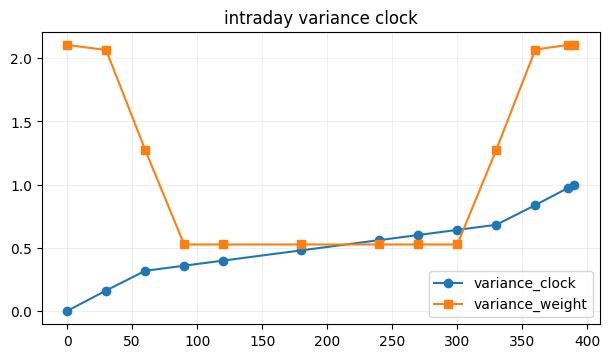

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("intraday variance clock")
ax.plot(data["minute"], data["variance_clock"], marker="o", label="variance_clock")
ax.plot(data["minute"], data["variance_weight"], marker="s", label="variance_weight")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## event/non-event jump intensity

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

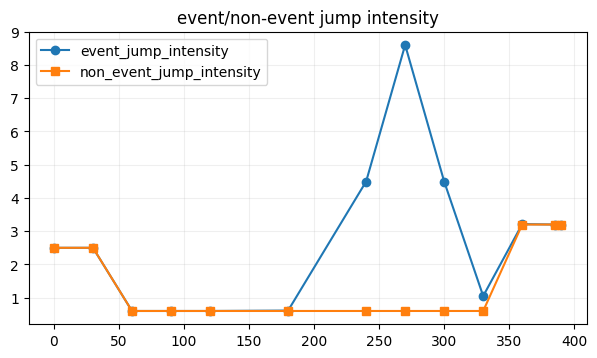

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("event/non-event jump intensity")
ax.plot(data["minute"], data["event_jump_intensity"], marker="o", label="event_jump_intensity")
ax.plot(data["minute"], data["non_event_jump_intensity"], marker="s", label="non_event_jump_intensity")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## adjacent-expiry total variance

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

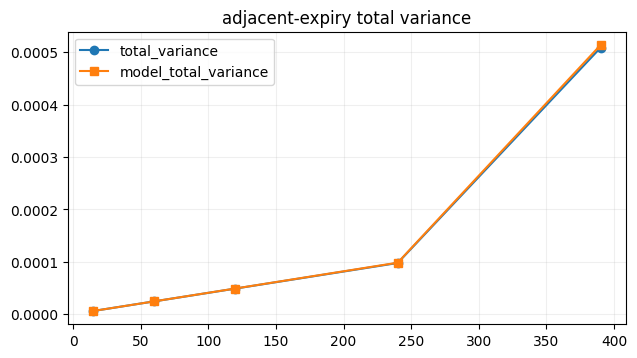

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("adjacent-expiry total variance")
ax.plot(data["adjacent_expiry_minutes"], data["total_variance"], marker="o", label="total_variance")
ax.plot(data["adjacent_expiry_minutes"], data["model_total_variance"], marker="s", label="model_total_variance")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## time-of-day price/Greek OOD

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

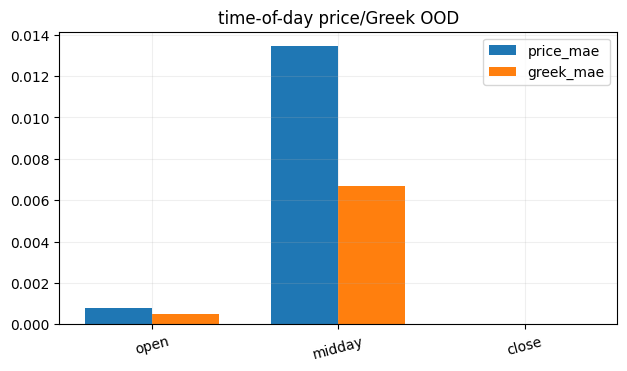

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("time-of-day price/Greek OOD")
x = np.arange(len(data["tod_names"]))
ax.bar(x - .18, data["price_mae"], width=.36, label="price_mae")
ax.bar(x + .18, data["greek_mae"], width=.36, label="greek_mae")
ax.set_xticks(x, data["tod_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [8]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

Andersen et al. (2024), ultra-short-dated options; scheduled-jump literature.

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。